**Name: Arun Gyawali**

**Course: Advanced Big Data and Data Mining (MSCS-634-M20)**

**Lab 1 : Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook**

In [32]:

import numpy as np
import pandas as pd

**STEP 1: Data Collection**

In [33]:

df = pd.read_csv("C:/Users/arung/OneDrive/Desktop/graduate/datamining/Lab1/taxi_fare.csv")
df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


**STEP 2 : Data Visualization**

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

**Visualization 1: Passenger Count Distribution**
   
    This chart shows how many passengers are recorded per taxi trip.

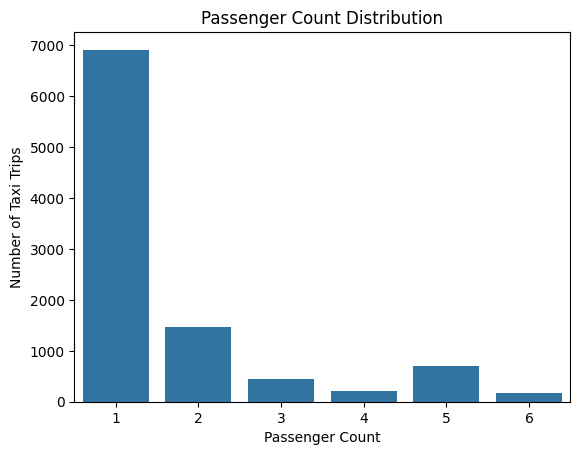

In [35]:
sns.countplot(x="passenger_count", data=df)

plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Taxi Trips")
plt.show()

The chart indicates that most taxi trips were taken by a single passenger, while trips with larger passenger groups occurred less frequently. This suggests that solo rides are the dominant trip type in the dataset. The visualization is useful before preprocessing because it helps understand the raw distribution of passenger counts and check for possible unusual values.

**Visualization 2: Pickup Location Scatter Plot**

This chart shows the geographic spread of taxi pickup locations using longitude and latitude.

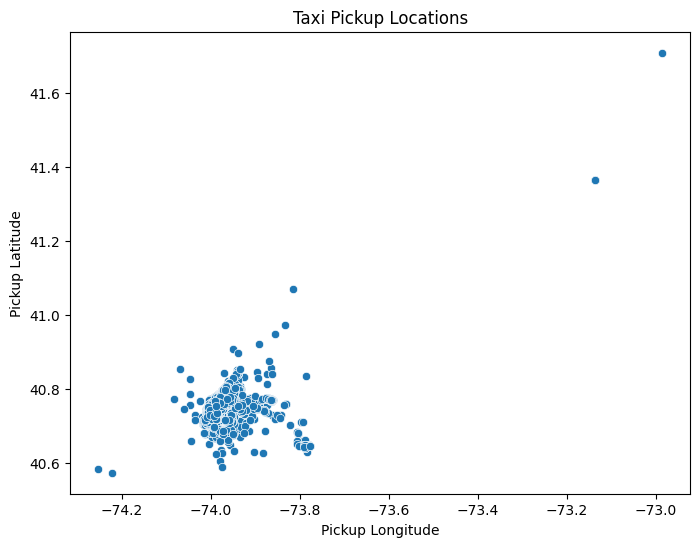

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = "pickup_longitude",
    y = "pickup_latitude",
    data = df
)

plt.title("Taxi Pickup Locations")
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")
plt.show()


The taxi pickup locations based on longitude and latitude. Most pickup points are concentrated in one dense geographic cluster, indicating that the majority of rides started within the main service area. A few points appear far from the main cluster, which may represent outliers or unusual location records. This visualization is useful before preprocessing because it helps identify the overall geographic pattern of the dataset and highlights records that may require further review during data cleaning.

**STEP 3: Data Preprocessing**

In [37]:
# Creating a copy so the original raw dataset is preserved
df_preprocess = df.copy()

# Display dataset before preprocessing
df_preprocess.head()


,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


**3.1. Handling Missing Values**

In [38]:
# Detect missing values in each column
missing_values = df_preprocess.isnull().sum()
missing_values

# Dataset before handling missing values
df_preprocess.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


In [39]:


# Filling missing numeric values with the mean
numeric_columns = df_preprocess.select_dtypes(include=["int64","float64"]).columns

for column in numeric_columns:
    df_preprocess[column] = df_preprocess[column].fillna(df_preprocess[column].mean())
    
# Filling missing categotical/object values with the mode
categorical_columns = df_preprocess.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df_preprocess[column] = df_preprocess[column].fillna(df_preprocess[column].mode()[0])
    
#Display missing values after handling
df_preprocess.isnull().sum()

key                  0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [40]:
# Dataset after handling missing values
df_preprocess.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


Missing values were checked using isnull().sum() to identify whether any columns contained incomplete records. This step is important because missing data can affect calculations, visualizations, and model accuracy. Numeric missing values were handled using mean replacement, while categorical missing values were handled using mode replacement. After this step, the dataset became more complete and ready for further preprocessing.

**3.2. Outlier Detection and Removal**

    For this dataset, we will use passenger_count because our chart already showed this column clearly.

In [41]:
# IQR calculation for passenger_count
Q1 = df_preprocess["passenger_count"].quantile(0.25)
Q3 = df_preprocess["passenger_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1: ", Q1)
print("Q3: ",Q3)
print("IQR: ",IQR)
print("Lower Bound: ",lower_bound)
print("Upper Bound: ",upper_bound)


Q1:  1.0
Q3:  2.0
IQR:  1.0
Lower Bound:  -0.5
Upper Bound:  3.5


In [42]:
# Identify outliers in passenger_count
outliers = df_preprocess[
    (df_preprocess["passenger_count"] < lower_bound) |
    (df_preprocess["passenger_count"] > upper_bound)
    ]

outliers.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
8835,2012-12-01 21:12:12.0000001,2012-12-01 21:12:12 UTC,-73.880419,40.741367,-73.880419,40.741367,4
8836,2014-06-14 13:39:00.00000071,2014-06-14 13:39:00 UTC,-73.993828,40.736100,-73.984260,40.743330,4
8837,2013-11-09 18:52:40.0000001,2013-11-09 18:52:40 UTC,-74.001771,40.719487,-74.006940,40.742592,4
8838,2013-11-09 18:52:40.0000003,2013-11-09 18:52:40 UTC,-73.961570,40.806277,-73.982355,40.776476,4
8839,2014-12-30 20:29:24.0000002,2014-12-30 20:29:24 UTC,-73.986906,40.736349,-74.003893,40.746687,4


In [43]:
# Remove outliers from passenger_count
df_no_outliers = df_preprocess[
    (df_preprocess["passenger_count"] >= lower_bound) &
    (df_preprocess["passenger_count"] <= upper_bound)
    ]

df_no_outliers.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


Outliers were detected using the IQR method. This method helped identify values that were unusually far from the normal range of the data. In this dataset, outlier handling was important because extreme values in columns such as passenger count, longitude, or latitude can distort statistical results. After removing outliers, the dataset became cleaner and more reliable for statistical analysis.

**3.3. Data Reduction**


In [44]:
# Dataset before data reduction
df_no_outliers.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


In [45]:
# Reduced dataset size by taking a 50% random sample
df_sampled = df_no_outliers.sample(frac=0.5, random_state=42)
df_sampled.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
8176,2011-04-03 03:46:18.0000001,2011-04-03 03:46:18 UTC,-73.951585,40.715042,-73.963627,40.719704,2
5884,2013-05-28 18:24:27.0000002,2013-05-28 18:24:27 UTC,-73.956517,40.786891,-73.953306,40.785239,1
2412,2010-09-20 16:48:00.00000076,2010-09-20 16:48:00 UTC,-73.991183,40.739162,-73.981065,40.746782,1
538,2014-06-15 07:06:00.0000006,2014-06-15 07:06:00 UTC,-73.976782,40.750930,-73.979702,40.746457,1
4354,2009-05-10 00:24:57.0000005,2009-05-10 00:24:57 UTC,-74.000915,40.741893,-73.988835,40.741363,1


In [46]:
# Drop less relevant columns
df_reduced = df_sampled.drop(columns=["key"])
df_reduced.head()

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
8176,2011-04-03 03:46:18 UTC,-73.951585,40.715042,-73.963627,40.719704,2
5884,2013-05-28 18:24:27 UTC,-73.956517,40.786891,-73.953306,40.785239,1
2412,2010-09-20 16:48:00 UTC,-73.991183,40.739162,-73.981065,40.746782,1
538,2014-06-15 07:06:00 UTC,-73.976782,40.750930,-73.979702,40.746457,1
4354,2009-05-10 00:24:57 UTC,-74.000915,40.741893,-73.988835,40.741363,1


Data reduction was performed by sampling the dataset and removing less relevant columns. Sampling reduced the number of rows while still keeping a representative portion of the data. The key column was removed because it mainly works as an identifier and does not directly help explain taxi trip patterns. This step made the dataset simpler and easier to analyze without losing important information.

**3.4. Data Scaling and Discretization**

In [47]:
# Dataset before scaling
df_reduced.head()

,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
8176,2011-04-03 03:46:18 UTC,-73.951585,40.715042,-73.963627,40.719704,2
5884,2013-05-28 18:24:27 UTC,-73.956517,40.786891,-73.953306,40.785239,1
2412,2010-09-20 16:48:00 UTC,-73.991183,40.739162,-73.981065,40.746782,1
538,2014-06-15 07:06:00 UTC,-73.976782,40.750930,-73.979702,40.746457,1
4354,2009-05-10 00:24:57 UTC,-74.000915,40.741893,-73.988835,40.741363,1


In [48]:
# Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

#Select numeric columns
numeric_columns = df_reduced.select_dtypes(include=["int64","float64"]).columns

# Apply Min-Max Scaling
scaler = MinMaxScaler()

df_scaled = df_reduced.copy()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

df_scaled.head()


,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
8176,2011-04-03 03:46:18 UTC,0.269652,0.168503,0.266124,0.180407,0.5
5884,2013-05-28 18:24:27 UTC,0.265228,0.260260,0.275291,0.263497,0.0
2412,2010-09-20 16:48:00 UTC,0.234132,0.199306,0.250635,0.214739,0.0
538,2014-06-15 07:06:00 UTC,0.247050,0.214335,0.251845,0.214327,0.0
4354,2009-05-10 00:24:57 UTC,0.225402,0.202794,0.243733,0.207868,0.0


In [49]:
# Discretization
#Creates passenger count categories
df_discretized = df_reduced.copy()

df_discretized["passenger_category"] = pd.cut(
    df_discretized["passenger_count"],
    bins=[0,1,3,6],
    labels=["Single Passenger","Small Group","Large Group"]
)
df_discretized[["passenger_count","passenger_category"]].head()


,passenger_count,passenger_category
8176,2,Small Group
5884,1,Single Passenger
2412,1,Single Passenger
538,1,Single Passenger
4354,1,Single Passenger


Scaling was applied to numerical columns to place the values within a common range. This is useful because columns such as latitude, longitude, and passenger count have different numerical scales. Discretization was also used to convert continuous or numeric values into meaningful categories. For example, passenger count can be grouped into categories such as single passenger, small group, and large group. This makes the data easier to interpret.

**STEP 4 : Statistical Analysis**

In [50]:
df_analysis = df_no_outliers.copy()

**4.1 General Overview of Data**

In [51]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8835 entries, 0 to 8834
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                8835 non-null   object 
 1   pickup_datetime    8835 non-null   object 
 2   pickup_longitude   8835 non-null   float64
 3   pickup_latitude    8835 non-null   float64
 4   dropoff_longitude  8835 non-null   float64
 5   dropoff_latitude   8835 non-null   float64
 6   passenger_count    8835 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 552.2+ KB


In [52]:
df_analysis.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,8835.000000,8835.000000,8835.000000,8835.000000,8835.000000
mean,-73.974717,40.751313,-73.973768,40.751663,1.268025
std,0.043229,0.034109,0.039470,0.035684,0.545353
min,-74.252193,40.573143,-74.263242,40.568973,1.000000
25%,-73.992467,40.736209,-73.991285,40.735152,1.000000
50%,-73.982225,40.753287,-73.979958,40.753992,1.000000
75%,-73.967716,40.767370,-73.964186,40.768703,1.000000
max,-72.986532,41.709555,-72.990963,41.696683,3.000000


The .info() function showed the structure of the dataset, including column names, data types, and non-null values. The .describe() function provided summary statistics such as count, mean, minimum, maximum, and quartile values. These outputs gave a quick overview of the dataset and helped confirm whether the data was ready for deeper analysis.

**4.2 Central Tendency Measures**

In [53]:
numeric_df = df_analysis.select_dtypes(include=["int64","float64"])

central_tendency = pd.DataFrame({
    "Minimum": numeric_df.min(),
    "Maximum": numeric_df.max(),
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0]
})

central_tendency

,Minimum,Maximum,Mean,Median,Mode
pickup_longitude,-74.252193,-72.986532,-73.974717,-73.982225,-73.137393
pickup_latitude,40.573143,41.709555,40.751313,40.753287,41.366138
dropoff_longitude,-74.263242,-72.990963,-73.973768,-73.979958,-73.982890
dropoff_latitude,40.568973,41.696683,40.751663,40.753992,40.762920
passenger_count,1.000000,3.000000,1.268025,1.000000,1.000000


Central tendency measures were calculated using minimum, maximum, mean, median, and mode. These values helped identify the typical patterns in the dataset. For example, the mean and median show the average behavior of numerical columns, while the mode shows the most frequently occurring value. These measures are useful for understanding the center of the data distribution.

**4.3 Dispersion measures**

In [54]:
Q1 = numeric_df.quantile(0.25)
Q2 = numeric_df.quantile(0.50)
Q3 = numeric_df.quantile(0.75)

dispersion = pd.DataFrame({
    "Range": numeric_df.max() - numeric_df.min(),
    "Q1": Q1,
    "Q2 / Median": Q2,
    "Q3": Q3,
    "IQR": Q3 - Q1,
    "Variance": numeric_df.var(),
    "Standard Deviation": numeric_df.std()
})

dispersion

,Range,Q1,Q2 / Median,Q3,IQR,Variance,Standard Deviation
pickup_longitude,1.265661,-73.992467,-73.982225,-73.967716,0.024750,0.001869,0.043229
pickup_latitude,1.136412,40.736209,40.753287,40.767370,0.031161,0.001163,0.034109
dropoff_longitude,1.272279,-73.991285,-73.979958,-73.964186,0.027098,0.001558,0.039470
dropoff_latitude,1.127710,40.735152,40.753992,40.768703,0.033551,0.001273,0.035684
passenger_count,2.000000,1.000000,1.000000,1.000000,0.000000,0.297410,0.545353


Dispersion measures such as range, quartiles, IQR, variance, and standard deviation were calculated to understand how spread out the data values were. A higher standard deviation or variance indicates that the values are more spread out from the mean. The IQR helped show the spread of the middle 50% of the data and was useful for identifying unusual values.

**4.4 Correlation Analysis**

In [55]:
correlation_matrix = numeric_df.corr()
correlation_matrix

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
pickup_longitude,1.000000,0.331198,0.454884,0.273839,0.019715
pickup_latitude,0.331198,1.000000,0.302211,0.534124,-0.012211
dropoff_longitude,0.454884,0.302211,1.000000,0.368023,0.010232
dropoff_latitude,0.273839,0.534124,0.368023,1.000000,-0.003239
passenger_count,0.019715,-0.012211,0.010232,-0.003239,1.000000


The correlation matrix was used to examine relationships between numerical columns. Correlation values help show whether two variables move together positively, negatively, or have little relationship. In the taxi fare dataset, this step helped identify whether variables such as pickup location, drop-off location, and passenger count had any meaningful relationship with each other.

**Conclusion**

Overall, the taxi fare prediction dataset was successfully loaded, visualized, preprocessed, and statistically analyzed. The visualizations provided an initial understanding of passenger count distribution and pickup location patterns. Preprocessing improved the quality of the dataset by handling missing values, removing outliers, reducing unnecessary data, and applying scaling and discretization. The statistical analysis then provided a deeper understanding of the dataset through summary statistics, central tendency, dispersion, and correlation analysis. These steps prepared the dataset for more accurate analysis and possible future machine learning tasks.